# Data Analysis with Python

Last week we introduced the very basics of Python: variables and some limited mathematical functions. If you need a refresher on those, feel free to go back to Lab 0 and look through them!

We have mentioned that the power of Python comes from **packages** or **modules** that add heaps of extra functionality to this simple language. We've seen one already: **NumPy**, or **Numerical Python**. Today, we are going to learn about 3 more packages, and see how can they be used to analyze data:

1. **Pandas**: a package for easy read in, storage and basic analysis of data (like spreadsheets).
1. **MatPlotLib**: a plotting package.
1. **SciPy**: **Scientific Python**, a package with tons of great science and statistics functions.
 ***

# Pandas - Data Manipulation Toolbox

When we do science in any lab, we usually record some data on a computer (for example, in Excel or some other software), and then we want to load it into Python and analyze it there. It is possible to do with basic Python or with NumPy, but the Pandas package makes our job much easier.

Pandas provides a really neat and visual framework to creating data tables (called **Data Frames**), or loading existing data into a Data Frame. It can also do some basic statistical analysis and plotting.
You can read more about Pandas here: https://pandas.pydata.org/

To get started, we load the Pandas module, similar to NumPy:

In [4]:
import pandas as pd

We give pandas a nickname, or an alias, and we now can access all of its functions by writing

**pd.function_name(function_variable)**

## DataFrames

Data Frames can store a variety of data, from numbers and text to more complicated objects. It is organized the same way a regular table would: it has columns, named after the type of information it stores, and rows with data.

You can easily create a DataFrame from some data you already have in a notebook, and we will cover how to do that later. However, of course, Python is not the most convenient tool for data taking. To this day, Excel still *Excels* at it (sorry!). Most of the labs, we will record the experiment results in Excel, and load it into a Jupyter notebook to analyze. With pandas, this is very easy!

To load in the data, use

In [6]:
#myData = pd.read_csv("data/masses.csv")    # This reads a CSV file into a table
myData = pd.read_excel("data/masses.xlsx") # This pandas method reads an excel file directly
myData   
# Try running and see what this does!

,Object,Trial,Volume (cm3),dV (cm3),Mass (g),dM (g),Extra notes
0,golf ball,1,41,1.000000e+00,6.200000e+01,1.000000e+00,measured
1,golf ball,2,39,1.000000e+00,5.800000e+01,1.000000e+00,measured
2,golf ball,3,37,1.000000e+00,5.600000e+01,1.000000e+00,measured
3,golf ball,4,40,1.000000e+00,6.200000e+01,1.000000e+00,measured
4,golf ball,5,42,1.000000e+00,6.400000e+01,1.000000e+00,measured
5,Taylor,1,920,1.000000e+01,6.300000e+02,1.000000e+01,measured
6,Human Heart,1,280,1.000000e+01,3.100000e+02,1.000000e+01,wiki
7,Coffee Cup,1,240,1.000000e+01,1.100000e+03,1.000000e+02,measured
8,Table,1,1300,1.000000e+02,2.000000e+04,1.000000e+03,measured
9,Reid,1,66400,1.000000e+02,8.000000e+04,1.000000e+03,he told us


#### Exercise: Open the `data/masses.xlsx` file with Excel.   Compare the spreadsheet with the table returned by printing the DataFrame. 

### Note on file paths

The only required argument for `read_excel(arguments)` is the **path** to the file. If the file is located in the same folder as the notebook, your life is easy! You can just specify the file name.

But, for better bookkeeping, you should have sub-folders in your Lab Directory, like on the image. Each Lab should have a folder for **data** and **images**, so that they do not mixed together. This simple habit will help you *a lot* in the future, whether you continue to doing research or work in some company!


<img src="images/filepath.png" width="700"/>

You need to tell Python how to find the masses file from the notebook: go to the **Data** folder, and look for the **masses.xlsx** file. <br>
*Note:* If you ever need to go *up one folder*, i.e. to a previous folder, you should use the **../** symbol!

**pd.read_xlsx("../data/masses.xlsx")**



## Looking at the data - Indexing Data Frames

Lets start by learning more about our data. <br>
Sometimes, you don't want to look at or analyze your entire data frame. Indexing, or selecting objects, from a data frame is very easy: you specify which objects you want using ***square brackets, [ ... ]***

For example, you might want to only look at one column, say the masses of the objects, paying no respect to what these objects are. Then, you say

## Looking at the data - Indexing Data Frames

Lets start by learning more about our data. <br>
Sometimes, you don't want to look at or analyze your entire data frame. Indexing, or selecting objects, from a data frame is very easy: you specify which objects you want using ***square brackets, [ ... ]***

For example, you might want to only look at one column, say the masses of the objects, paying no respect to what these objects are. Then, you say

In [7]:
myData["Mass (g)"]

0     6.200000e+01
1     5.800000e+01
2     5.600000e+01
3     6.200000e+01
4     6.400000e+01
5     6.300000e+02
6     3.100000e+02
7     1.100000e+03
8     2.000000e+04
9     8.000000e+04
10    1.700000e-25
11    4.610000e+14
Name: Mass (g), dtype: float64

Finally, Pandas lets you chose rows that satisfy a **condition**: for example, you want to look only at data you measured yourself, and not at data you got from somewhere else.

In [8]:
myData[ myData["Extra notes"] == "measured" ]

,Object,Trial,Volume (cm3),dV (cm3),Mass (g),dM (g),Extra notes
0,golf ball,1,41,1.0,62.0,1.0,measured
1,golf ball,2,39,1.0,58.0,1.0,measured
2,golf ball,3,37,1.0,56.0,1.0,measured
3,golf ball,4,40,1.0,62.0,1.0,measured
4,golf ball,5,42,1.0,64.0,1.0,measured
5,Taylor,1,920,10.0,630.0,10.0,measured
7,Coffee Cup,1,240,10.0,1100.0,100.0,measured
8,Table,1,1300,100.0,20000.0,1000.0,measured


And you can combine these tools using multiple brackets! For example, if we only want to see the masses of the measured objects,

In [9]:
myData[ myData["Extra notes"] == "measured" ]["Mass (g)"]

0       62.0
1       58.0
2       56.0
3       62.0
4       64.0
5      630.0
7     1100.0
8    20000.0
Name: Mass (g), dtype: float64

## Operations on the data in DataFrames

It is often useful to perform an operation on a column of data and save this new value in the dataFrame. 

For example, suppose we want to calculate the mass squared for each row of the DataFrame. 

In [10]:
myData["Mass Squared (g2)"] = myData["Mass (g)"]**2   # creates a new column (series) in the DataFrame
myData                         # print the DataFrame again... notice the new column that we've created

,Object,Trial,Volume (cm3),dV (cm3),Mass (g),dM (g),Extra notes,Mass Squared (g2)
0,golf ball,1,41,1.000000e+00,6.200000e+01,1.000000e+00,measured,3.844000e+03
1,golf ball,2,39,1.000000e+00,5.800000e+01,1.000000e+00,measured,3.364000e+03
2,golf ball,3,37,1.000000e+00,5.600000e+01,1.000000e+00,measured,3.136000e+03
3,golf ball,4,40,1.000000e+00,6.200000e+01,1.000000e+00,measured,3.844000e+03
4,golf ball,5,42,1.000000e+00,6.400000e+01,1.000000e+00,measured,4.096000e+03
5,Taylor,1,920,1.000000e+01,6.300000e+02,1.000000e+01,measured,3.969000e+05
6,Human Heart,1,280,1.000000e+01,3.100000e+02,1.000000e+01,wiki,9.610000e+04
7,Coffee Cup,1,240,1.000000e+01,1.100000e+03,1.000000e+02,measured,1.210000e+06
8,Table,1,1300,1.000000e+02,2.000000e+04,1.000000e+03,measured,4.000000e+08
9,Reid,1,66400,1.000000e+02,8.000000e+04,1.000000e+03,he told us,6.400000e+09


## Pandas Series

When you select a column of data from a dataFrame you are looking at a Pandas object called a `Series`.   Pandas provides many useful operations for a series.   Below are some examples:

In [11]:
myVolumes = myData["Volume (cm3)"]
print("min =",    myVolumes.min())   # .min()  returns the minimum value of the series
print("max =",    myVolumes.max())   # .max()  returns the maximum value of the series
print("mean =",   myVolumes.mean())  # .mean() returns the mean or average of the series
print("stdev = ", myVolumes.std())   # .std()  returns the standard deviation of the series  

min = 0
max = 490000000000000
mean = 40833333339111.586
stdev =  141450815949638.62


There are MANY operations that Pandas provides for series.   You can see some of them under the "Methods" heading in the Pandas documentation here: <br> https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.html

***

# MatPlotLib - Plotting Tools for Python

In any scientific paper or presentation, plots are usually the most important part - they summarize your results in a visual and a clear way. Of course, lab experiments are no different, so plotting is very important! 

The plotting tools we will use are part of a python module called MatPlotLib, short for MatLab Plot Library, since most of its tools and capabilities are based off of plotting with the program MatLab. You can learn much more about MatPlotLib here: http://matplotlib.org/.

Plotting with MatPlotLib can be confusing, but their website provides a lot of useful plot examples with the code that is needed to produce them. If you are ever stuck not knowing how to do code something you want on your plot, look for an example that does it and see how it works!

In order to get started, we need to import the plotting tools from the MatPlotLib module and also tell our Jupyter Notebook how we want it to make plots. We'll need to run the two commands in the next cell:

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

The first command imports the MatPlotLib plotting tools and gives the module the alias **plt** 

The second command tells the Jupyter notebook that when we use a plotting command, the Notebook should visualize the plots right inside our notebook. Jupyter has other plot visualization settings, but we will stick with these for now.

It is generally a good practice to put all of your import commands in a single cell.

## Plotting Data With the *plot()* and *errorbar()* Functions

The workhorse function of MatPlotLib is the **plot()** function that you can call as `plt.plot()`. 
We can plot data by giving the function x and y data as arguments: `plt.plot(xdata, ydata)`. 

In the lab we usually want to represent the error bars on the plot as well as our data, so we will often use a different function: **errrorbar()**. It is used as:

`plt.errorbar(xdata, ydata, yerr=yerr, xerr=xerr, fmt="o")`

Let's break this function down:

- `xdata` and `ydata` are x- and y- values
- `xerr` and `yerr` are x- and y- uncertainties
- `fmt` is the format of the plot

The x and y data/uncertainties can be python lists, pandas columns or numpy arrays (we will cover those later).

#### Format

`fmt` function sets the format of your plot, using 3 arguments passed as one string. It decides 3 things (in this order): 

1. The line/marker color (**r** = **r**ed, **b**=**b**lue... the weird one is **k** = blac**k**, none = default MatPlotLib colorscheme)
2. The marker style (**o** = circles, **.** = points, none = no marker)
3. The line style the line style (**--** = dashed, **-** = solid, none = no line)

As long as you keep the order right, you can just combine these in one string. For example, `fmt="bo--"` plots a blue dashed line connecting circular points and `fmt="o"` plots just the points, without a line connecting them, in default MatPlotLib colors.

In [1]:
# Select only the light objects from the data. There is no point plotting all humanity on the same axis
# light_objects is a pandas dataframe of all measured masses less than 10kg
light_objects = myData[ myData["Mass (g)"] < 10000]  

#x1 and y1 are each pandas series
#x1 a series of all the "Object" items in the light_objects dataframe
#y1 a series of all the "Mass (g)" items in the light_objects dataframe
x1 = light_objects["Object"]
y1 = light_objects["Mass (g)"]

x2 = light_objects["Object"]
y2 = light_objects["Volume (cm3)"]

plt.errorbar(x1, y1, yerr=light_objects["dM (g)"], fmt="o-")
plt.errorbar(x2, y2, yerr=light_objects["dV (cm3)"],  fmt="k--")


NameError: name 'myData' is not defined

Notice that both plot commands were plotted on the same figure. By default, the first line always shows up in blue, and the second one in orange.

## Adding Text to the Plot

You can add a legend by using the **plt.legend()** function. Before you add a legend, you need to make sure you give each of the curves you've plotted *labels*. You give your curves labels by using the *label* keyword in the **plt.plot()** function. 

You can change the font size of the legend by using the *fontsize* keyword in **plt.legend()**, e.g., `plt.legend(fontsize = 20)`.

You can add axis labels and a title to the plot with: **plt.xlabel()**, **plt.ylabel()**, and **plt.title()** (and can use the **fontsize** keyword to adjust the font size)



Text(0.5, 1.0, 'My Figure Title')

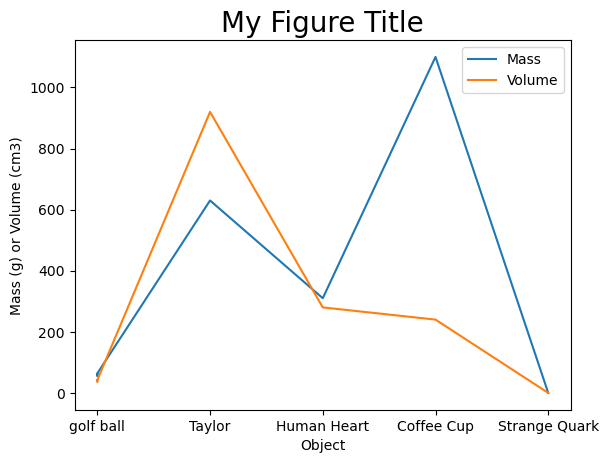

In [14]:
#Plot data
plt.plot(x1,y1,label='Mass')
plt.plot(x2,y2,label='Volume')
plt.legend()
plt.xlabel('Object')
plt.ylabel('Mass (g) or Volume (cm3)')
plt.title('My Figure Title', fontsize = 20)

### Saving Figures

You can save your figure to a file using the **plt.savefig()** function. The argument of the function is the name of the file you want it to save your plot to and its path. MatPlotLib can recognize most common file formats like .png, .jpeg, .pdf.

    plt.savefig('images/my_first_plot.png')
    
*Note:* if you are providing a folder name, this folder must **exist** before you save to it. 

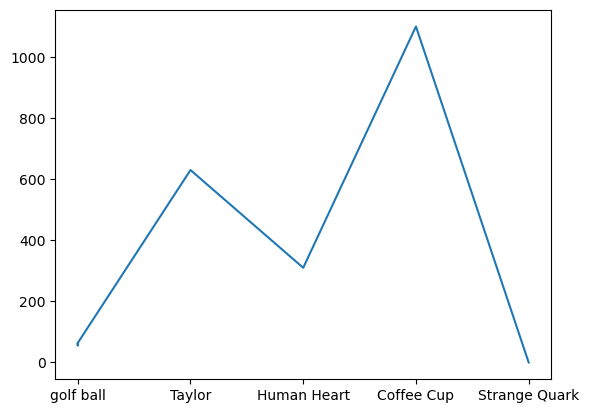

In [15]:
plt.plot(x1, y1, label="Mass") #create the plot
plt.savefig("images/my_first_plot.png")

***

# SciPy - Data Analysis Toolbox

In the laboratory and in science in general, we want to figure out the ***relationship*** between different things we measure. Often, we want to test if the data follows some **model**, or assume some model to try to figure out some unknown quantity. This, and many more things, can be done with the SciPy package.

For the first part of this course, the most we will do with this powerful package is fitting simple models (such as straight lines) to our data. The easiest way to do so is using **curve_fit()** function from **scipy.optimize** toolbox.

First, import **scipy.optimize**:

In [ ]:
import scipy.optimize as opt

### `curve_fit()`

The **curve_fit()** function is used like this:

   `p, cov = curve_fit( model,  xdata,  ydata,  sigma,  absolute_sigma=True )`

Let's break this function down.

#### INPUT :

* The **model** is the function we try to fit for our data. Most of the time, we try to fit a straight line, so our model is **y = A + Bx**. The parameters we try to figure out are then **A** and **B**
* **xdata** and **ydata** are the data arrays. They can be Pandas columns, Python lists or Numpy arrays.
* **sigma** is the list of uncertainties in y. Unfortunately, **curve_fit** can't account for uncertainties in x, but we will learn later how to incorporate these in our y-uncertainties.
* **Absolute_sigma** is a parameter you should always set to True. This basically means that the uncertainties are the same in the positive and negative direction.

#### OUTPUT :
The function *returns* two objects that we save to variables **p** and **cov**.

* **p** is the guess for our parameters: **p = [A, B]**
* **cov** is something called *covariance matrix*. You don't need to worry about the whole thing for now, but this is where we get the uncertainty estimates on **A** and **B**.

If we output **p** and **cov** this way, then we get **A**, **B** and their uncertainties using

$$ \textrm{A} = \textrm{p}[0] \quad \textrm{and} \quad \textrm{B} = \textrm{p}[1] $$

$$ \delta \textrm{A} = \sqrt{\textrm{cov}[0,0] } \quad\textrm{and}\quad \delta \textrm{B} = \sqrt{\textrm{cov}[1,1]} $$


It looks scary, but you will quickly get the hang of it! It's easiest to show how this works with an example. <br>
Let's go back to our data from before. We measured the mass and the volume of 5 different golf balls, and try to figure out their ***density***. 


In [ ]:
golf_volumes  = myData[ myData["Object"] == "golf ball"]["Volume (cm3)"]  # series of volumes (in cm^3)
golf_dvolumes = myData[ myData["Object"] == "golf ball"]["dV (cm3)"]      # series of volume errors (in cm^3)
golf_masses   = myData[ myData["Object"] == "golf ball"]["Mass (g)"]      # series of masses (in grams)
golf_dmasses  = myData[ myData["Object"] == "golf ball"]["dM (g)"]        # series of mass errors (in grams)

From your previous physics classes, you probably know that

$$ \textrm{Mass} = \textrm{Volume} \times \textrm{Density} $$

So if we plot **Mass** on y-axis and **Volume** on x-axis, we should get a straight line with the slope equal to **Density**.

In [ ]:
plt.errorbar(golf_volumes, golf_masses, yerr=golf_dmasses, xerr=golf_dvolumes, fmt="o")

Now we want to fit a straight line using **curve_fit** function. 

The first thing we need to do is to define our model. We already know that the model is just a straight line: 

$$\textrm{Mass} = A + B \times \textrm{Volume} $$

Based on our knowledge, we expect **A** to be nearly 0, and **B** to give us the density.

The **model** we pass to the **curve_fit** has to be defined as a **function**. Although we didn't say this explicitly, you have already been using lots of functions - that someone else has defined for you, for example the programmers at NumPy. To define your own function, use this structure:

In [ ]:
def my_line_model(x, A, B):
    y = A + B*x
    return y

The function has 3 major parts:
    
1. **Definition keyword `def`, name `my_line_model` and input variables `(x, A, B)`** <br>
   The definition simply tells Python a new function is being defined! The name can be anything you want, but you should keep it descriptive. Finally, the variables are the names of any parameters you think the function will need to return its output (in our case, a value for y).
2. **Function body** <br>
   Function body follows after a `:` and is always indented by **1 tab** (4 spaces). Everything that follows `def` and is indented this way is a part of a function. This is what the function **does** to return its output.
3. **`return` statement.** <br>
    Most of the times, we want our functions to return some answer that we use later, like `c = add(a, b)` would `return a+b`. 
    
Now that we have a function, we can finally use **curve_fit**!

In [ ]:
# Run the curve_fit function.
# Remember the syntax: p, cov = curve_fit(model,  xdata,  ydata,  sigma, absolute_sigma=True )

# Model          =   my linear model that I'll try to fit with, my_line_model
# xdata          =   golf_masses
# ydata          =   golf_masses
# sigma          =   golf_dmasses, uncertainty in the y variable
# p0             =   initial parameter guesses: A=0, B=1.5.
# absolute_sigma = will always be set to True

fit_param, fit_param_errors = opt.curve_fit(my_line_model,  
                                            golf_volumes,  
                                            golf_masses,  
                                            sigma=golf_dmasses,
                                            absolute_sigma=True )

Let's look at our results!

In [ ]:
import numpy as np    # To access the square root function

# The value of A, the uncertainty in A
fitA = fit_param[0]
fitdA = np.sqrt(fit_param_errors[0,0])   

# The value of B, the uncertainty in B
fitB = fit_param[1]
fitdB = np.sqrt(fit_param_errors[1,1])    

print(fitA, fitdA)
print(fitB, fitdB)

If you have already done the reading for this lab (**Taylor pp. 14-16, Chapter 2.2: Significant Figures**), you know by now that the correct way to present your answers is using the right number of **significant figures**. After all, if we are only certain what the density is up to $0.3\textrm{ g/cm}^3$, there is no point specifying it to a $100^{\textrm{th}}$ digit, is there!

Specifying the correct number of significant figures is tricky in Python, but specifying **decimal places** is very easy. You just need to think how many decimal places you want. 

The **print** function comes with a powerful **formatting** tool that formats whatever you want to print the way you want it. You can change cases on strings, you can make things appear in exponential notation, and - you can specify decimal places. You can read more about the different formatting options here: https://www.python-course.eu/python3_formatted_output.php

To format the output of a print statement, we use

In [ ]:
print("My measured density: %2.1f +/- %2.1f g/cm3" % (fitB, fitdB))

Let's break this down a bit.

- `%`2.1f means "here is where my number goes", specified by the number in brackets, at the end of the string and after the second `%`. If you have 2 numbers you want to insert, the numberes in brackets should be in the order you want them to appear.
- %2.1`f` means "my number is a float". You can use `f` for floats, `i` for integers, `e` for numbers in the form `2e3`, and `s` for strings.
- %`2`.1f means "my number should take at least 2 spaces". I always use 2, but if you want lots of space around the number, you can use bigger values.
- %2.`.1`f means "my number should have 1 decimal place".

After just a few lines of code (and I promise, you will get the hang of it) we get our model!

$$ A = -5 \pm 10 \quad \textrm{and} \quad B = 1.6 \pm 0.3 $$

$$ \textrm{Mass} = (-5 \pm 10) + (1.6 \pm 0.3) \times \textrm{Volume} $$

So our golf balls have an average density of **1.6 +/- 0.3 g/cm3 **. Cool, right? Let's plot the line of best fit on the plot and save it!


In [ ]:
#plot the data w/ error bars
plt.errorbar(golf_volumes, 
             golf_masses, 
             yerr=golf_dmasses, 
             fmt="o", 
             label="Data") 

#plot the fit model: x=golf_volumes, y=model fit results
plt.plot(golf_volumes, 
         my_line_model(golf_volumes,fitA,fitB), 
         label="Model")  

# make the plot more beautiful
plt.xlabel("Volume (cm3)")
plt.ylabel("Mass (g)")
plt.title("Volumes and masses of 5 golf balls")
plt.legend()

plt.savefig("images/golf_density.png")

And that's it! It is a lot, but you will soon get the hang of it. The best way to learn Python is by trying out different things with it, so go ahead and try following these same steps on the Lab Assignment 1. Good luck! :)

In [2]:
print(f" 2 * g = {par[0]}")
print(f"g = {par[0] / 2}")

NameError: name 'par' is not defined